In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv('../datasets/Social_Network_Ads.csv')
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [12]:
df = df[['Age', 'EstimatedSalary', 'Purchased']]
df.shape

(400, 3)

In [13]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


## Split Input & Output Features

In [14]:
X = df.iloc[:,:2]
y = df.iloc[:,2:]

X,y

(     Age  EstimatedSalary
 0     19            19000
 1     35            20000
 2     26            43000
 3     27            57000
 4     19            76000
 ..   ...              ...
 395   46            41000
 396   51            23000
 397   50            20000
 398   36            33000
 399   49            36000
 
 [400 rows x 2 columns],
      Purchased
 0            0
 1            0
 2            0
 3            0
 4            0
 ..         ...
 395          1
 396          1
 397          1
 398          0
 399          1
 
 [400 rows x 1 columns])

## Train Test Split

In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_test, y_train, y_test

(     Age  EstimatedSalary
 3     27            57000
 18    46            28000
 202   39           134000
 250   44            39000
 274   57            26000
 ..   ...              ...
 71    24            27000
 106   26            35000
 270   43           133000
 348   39            77000
 102   32            86000
 
 [320 rows x 2 columns],
      Age  EstimatedSalary
 209   46            22000
 280   59            88000
 33    28            44000
 210   48            96000
 93    29            28000
 ..   ...              ...
 246   35            50000
 227   56           133000
 369   54            26000
 176   35            47000
 289   37            78000
 
 [80 rows x 2 columns],
      Purchased
 3            0
 18           1
 202          1
 250          0
 274          1
 ..         ...
 71           0
 106          0
 270          0
 348          0
 102          0
 
 [320 rows x 1 columns],
      Purchased
 209          0
 280          1
 33           0
 210          1


## Standardization

In [70]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit on the training data
scaler.fit(X_train)
# transform both
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# X_train, X_test --> both pandas DataFrame
# X_train_scaled, X_test_scaled --> numpy arrays
X_train_scaled = pd.DataFrame(X_train_scaled, columns=['Age', 'EstimatedSalary'])
X_test_scaled = pd.DataFrame(X_test_scaled, columns=['Age', 'EstimatedSalary'])
X_train_scaled, X_test_scaled

(          Age  EstimatedSalary
 0   -1.066752        -0.386344
 1    0.797535        -1.229939
 2    0.110692         1.853544
 3    0.601294        -0.909955
 4    1.876859        -1.288118
 ..        ...              ...
 315 -1.361114        -1.259028
 316 -1.164873        -1.026312
 317  0.503174         1.824455
 318  0.110692         0.195445
 319 -0.576151         0.457250
 
 [320 rows x 2 columns],
          Age  EstimatedSalary
 0   0.797535        -1.404475
 1   2.073100         0.515429
 2  -0.968632        -0.764507
 3   0.993775         0.748145
 4  -0.870512        -1.229939
 ..       ...              ...
 75 -0.281789        -0.589971
 76  1.778738         1.824455
 77  1.582498        -1.288118
 78 -0.281789        -0.677239
 79 -0.085549         0.224534
 
 [80 rows x 2 columns])

In [71]:
np.round(X_train.describe(), 1)

,Age,EstimatedSalary
count,320.0,320.0
mean,37.9,70281.2
std,10.2,34430.6
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,71000.0
75%,45.0,88000.0
max,60.0,150000.0


In [72]:
# after scaling, the mean of both features has become 0 & standard deviation has become 1
np.round(X_train_scaled.describe(),1)

,Age,EstimatedSalary
count,320.0,320.0
mean,-0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.7,0.5
max,2.2,2.3


Text(0.5, 1.0, 'After Scaling')

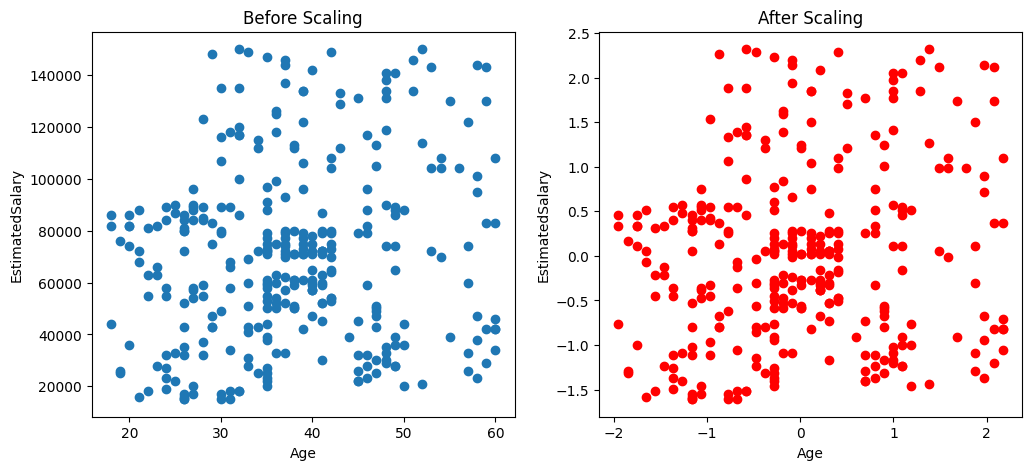

In [73]:
# 1 row , 2 col
# side by side plot
# fig represents empty canvas
# axes ndarray - axes[0] represents left plot, axes[1] represents right plot
# figsize(12,5) represents width and height - 12 inches width and 5 inches height
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].scatter(X_train['Age'], X_train['EstimatedSalary'])
axes[0].set_xlabel('Age')
axes[0].set_ylabel('EstimatedSalary')
axes[0].set_title('Before Scaling')

axes[1].scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'], color='red')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('EstimatedSalary')
axes[1].set_title('After Scaling')


# These scatter plots clearly reflect that distribution of values stays same and is unchanged because of scaling


/var/folders/tr/k980qy9n2kl4d_dmml8c0k780000gn/T/ipykernel_96946/3598365649.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
/var/folders/tr/k980qy9n2kl4d_dmml8c0k780000gn/T/ipykernel_96946/3598365649.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


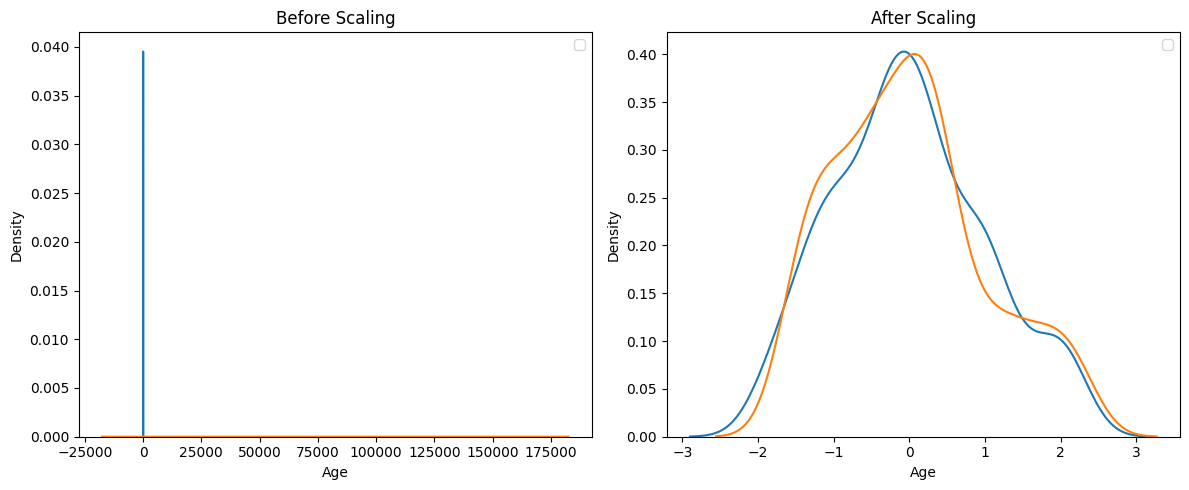

In [74]:
# For plotting a PDF (Probability Density Function), we will use seaborn's Kernel Density Estimation (KDE) plot.
fig, axes = plt.subplots(1,2,figsize = (12,5))

sns.kdeplot(X_train['Age'], ax=axes[0])
sns.kdeplot(X_train['EstimatedSalary'], ax=axes[0])

axes[0].set_title('Before Scaling')
axes[0].legend()
# Before scaling: for age within a very small range we were getting lots of values. Hence the density shot up
# for salary, the values are quite spread - hence getting a flat line
# This happens because the two features are on completely different scales

# When both distributions are plotted on the same x-axis, Salary's large values stretch the axis so much that
# Age gets compressed into a tiny region near zero.

# Key Observation:

# You cannot meaningfully compare the distributions.
# The feature with the larger magnitude (Salary) dominates the visualization.
# This is exactly the same problem many ML algorithms face before scaling.


sns.kdeplot(X_train_scaled['Age'], ax=axes[1])
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=axes[1])

axes[1].set_title('After Scaling')
axes[1].legend()

# after scaling: 
# Both distributions are centered around 0.
# Both have approximately unit standard deviation.
# The two curves now occupy the same range

# Key Observation:

# The original shapes of the distributions are preserved.
# Only the location and scale have changed.
# You can now directly compare the distributions of Age and Salary.

plt.tight_layout()

# Most important insight:
# Standardization does not change the shape of the distribution.
# It only changes the 
#     Location (mean)
#     Scale (standard deviation)

## Distribution Comparisons

Text(0.5, 1.0, 'After Scaling')

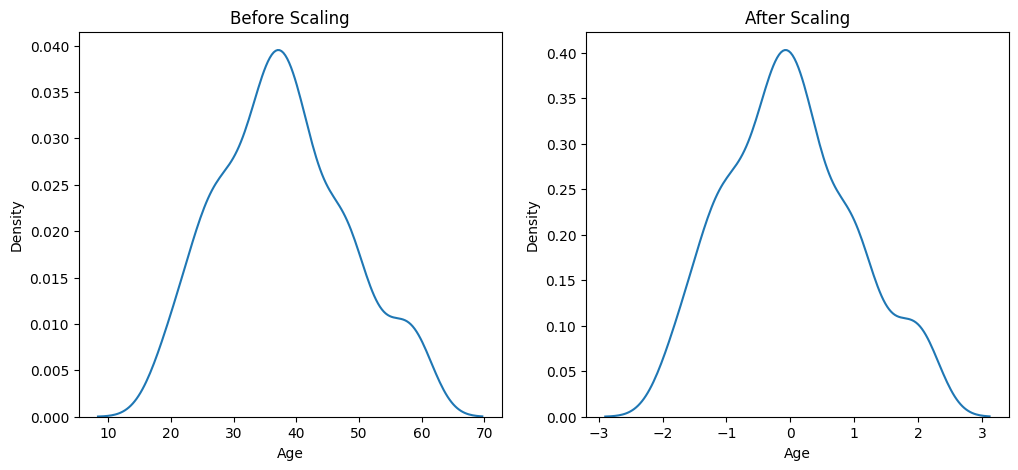

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.kdeplot(X_train['Age'], ax=axes[0])
axes[0].set_title('Before Scaling')

sns.kdeplot(X_train_scaled['Age'], ax=axes[1])
axes[1].set_title('After Scaling')

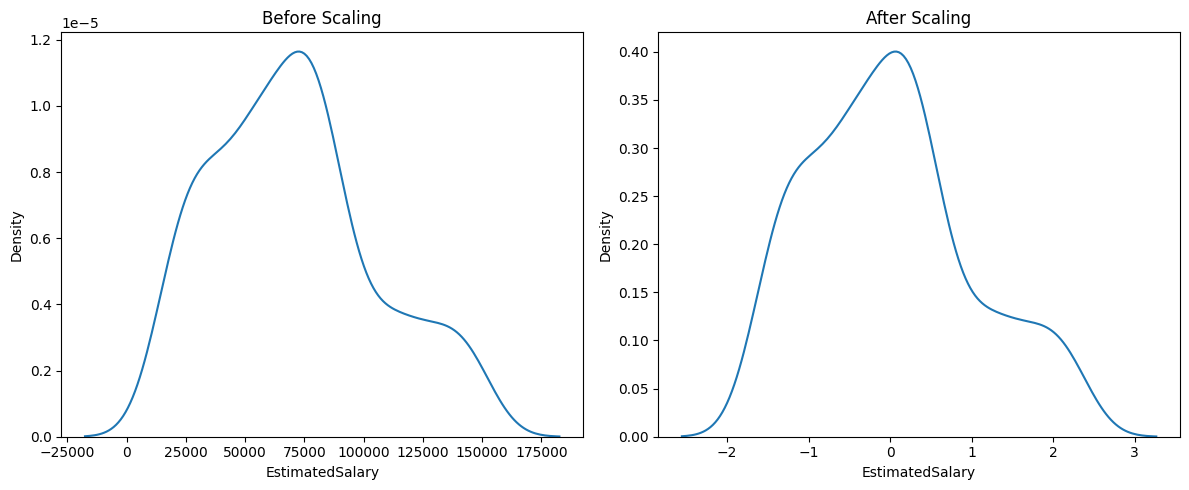

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.kdeplot(X_train['EstimatedSalary'], ax=axes[0])
axes[0].set_title('Before Scaling')

sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=axes[1])
axes[1].set_title('After Scaling')

plt.tight_layout()

In [77]:
# It is clear from the above scatter plots that scaling has no impact on distributions

## Why scaling is important?

In [78]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [79]:
# In logistic regression, we need to provide scaled values in order to get better results
# In this experiment we will be comparing the results when values are scaled vs when values are not scaled
lr.fit(X_train, y_train.values.ravel())
lr_scaled.fit(X_train_scaled, y_train.values.ravel())

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [80]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [84]:
from sklearn.metrics import accuracy_score

print('Actual', accuracy_score(y_test, y_pred))
print('Scaled', accuracy_score(y_test, y_pred_scaled))


Actual 0.8875
Scaled 0.8625


In [85]:
print(lr.coef_)
print(lr_scaled.coef_)

[[2.07808219e-01 3.54979001e-05]]
[[1.96509784 1.13509021]]


In [86]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))
print(classification_report(y_test, y_pred_scaled))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92        52
           1       0.91      0.75      0.82        28

    accuracy                           0.89        80
   macro avg       0.90      0.86      0.87        80
weighted avg       0.89      0.89      0.88        80

              precision    recall  f1-score   support

           0       0.85      0.96      0.90        52
           1       0.90      0.68      0.78        28

    accuracy                           0.86        80
   macro avg       0.88      0.82      0.84        80
weighted avg       0.87      0.86      0.86        80



In [89]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

dt.fit(X_train, y_train)
dt_scaled.fit(X_train_scaled, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [90]:
y_pred = dt.predict(X_test)
y_pred_scaled = dt_scaled.predict(X_test_scaled)

In [91]:
from sklearn.metrics import accuracy_score
print('Actual', accuracy_score(y_test, y_pred))
print('Scaling', accuracy_score(y_test, y_pred_scaled))

# scaling has no impact in DecisionTree -- we are getting same accuracy

Actual 0.8375
Scaling 0.8375


In [92]:
# Generally scaling has no harm, but there are only certain instances where it helps

## Effect of Outlier

In [100]:
df.describe(), df.shape

(              Age  EstimatedSalary   Purchased
 count  400.000000       400.000000  400.000000
 mean    37.655000     69742.500000    0.357500
 std     10.482877     34096.960282    0.479864
 min     18.000000     15000.000000    0.000000
 25%     29.750000     43000.000000    0.000000
 50%     37.000000     70000.000000    0.000000
 75%     46.000000     88000.000000    1.000000
 max     60.000000    150000.000000    1.000000,
 (400, 3))

In [104]:
df = pd.concat([
        df, 
        pd.DataFrame({
                'Age':[5,90,95],
                'EstimatedSalary': [1000, 250000, 350000],
                'Purchased':[0,1,1]
        })
    ],ignore_index=True)

In [105]:
df.shape

(403, 3)

In [106]:
X = df.iloc[:,:2]
y = df.iloc[:,2:]

X,y

(     Age  EstimatedSalary
 0     19            19000
 1     35            20000
 2     26            43000
 3     27            57000
 4     19            76000
 ..   ...              ...
 398   36            33000
 399   49            36000
 400    5             1000
 401   90           250000
 402   95           350000
 
 [403 rows x 2 columns],
      Purchased
 0            0
 1            0
 2            0
 3            0
 4            0
 ..         ...
 398          0
 399          1
 400          0
 401          1
 402          1
 
 [403 rows x 1 columns])

In [107]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_test, y_train, y_test

(     Age  EstimatedSalary
 353   37            57000
 233   49            86000
 3     27            57000
 18    46            28000
 131   33            31000
 ..   ...              ...
 71    24            27000
 106   26            35000
 270   43           133000
 348   39            77000
 102   32            86000
 
 [322 rows x 2 columns],
      Age  EstimatedSalary
 70    25            80000
 281   35            61000
 283   52            21000
 33    28            44000
 42    35           108000
 ..   ...              ...
 45    23            20000
 90    22            81000
 248   41            52000
 337   35            79000
 390   48            33000
 
 [81 rows x 2 columns],
      Purchased
 353          0
 233          1
 3            0
 18           1
 131          0
 ..         ...
 71           0
 106          0
 270          0
 348          0
 102          0
 
 [322 rows x 1 columns],
      Purchased
 70           0
 281          0
 283          1
 33           0


In [108]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit on the training data
scaler.fit(X_train)
# transform both
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# X_train, X_test --> both pandas DataFrame
# X_train_scaled, X_test_scaled --> numpy arrays
X_train_scaled = pd.DataFrame(X_train_scaled, columns=['Age', 'EstimatedSalary'])
X_test_scaled = pd.DataFrame(X_test_scaled, columns=['Age', 'EstimatedSalary'])
X_train_scaled, X_test_scaled

(          Age  EstimatedSalary
 0   -0.108424        -0.385373
 1    0.968573         0.352199
 2   -1.005922        -0.385373
 3    0.699324        -1.122946
 4   -0.467424        -1.046645
 ..        ...              ...
 317 -1.275172        -1.148380
 318 -1.095672        -0.944911
 319  0.430074         1.547576
 320  0.071075         0.123297
 321 -0.557173         0.352199
 
 [322 rows x 2 columns],
          Age  EstimatedSalary
 0  -1.185422         0.199598
 1  -0.287924        -0.283639
 2   1.237822        -1.300981
 3  -0.916172        -0.716009
 4  -0.287924         0.911737
 ..       ...              ...
 76 -1.364921        -1.326414
 77 -1.454671         0.225032
 78  0.250575        -0.512541
 79 -0.287924         0.174164
 80  0.878823        -0.995778
 
 [81 rows x 2 columns])

Text(0.5, 1.0, 'After Scaling')

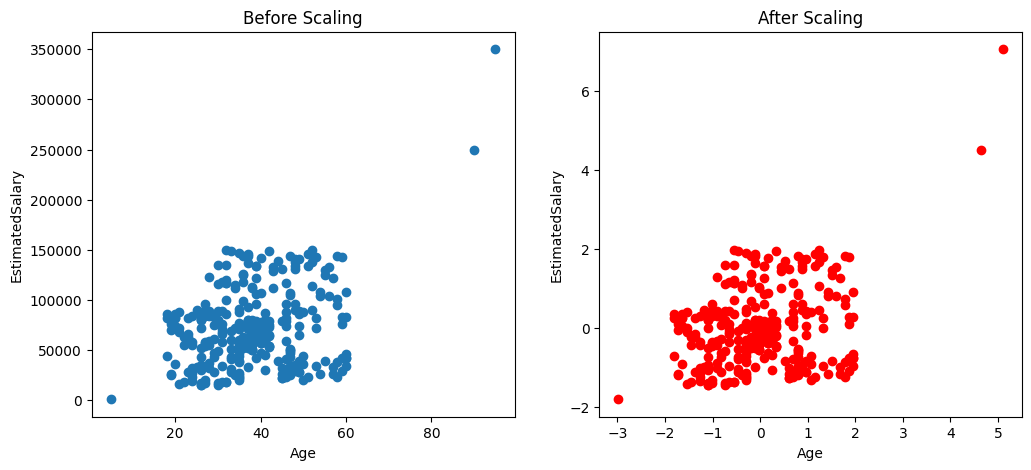

In [109]:
# 1 row , 2 col
# side by side plot
# fig represents empty canvas
# axes ndarray - axes[0] represents left plot, axes[1] represents right plot
# figsize(12,5) represents width and height - 12 inches width and 5 inches height
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].scatter(X_train['Age'], X_train['EstimatedSalary'])
axes[0].set_xlabel('Age')
axes[0].set_ylabel('EstimatedSalary')
axes[0].set_title('Before Scaling')

axes[1].scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'], color='red')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('EstimatedSalary')
axes[1].set_title('After Scaling')


# These scatter plots clearly reflect that distribution of values stays same and is unchanged because of scaling


In [ ]:
# These plots clearly shows that scaling has no impact on outliers. You will need to handle them separately.